<a href="https://colab.research.google.com/github/MartaPCastillo/Tesis/blob/main/Grupo%20M%C3%A9xico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 15.1 MB/s eta 0:00:00


In [90]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 25.2 MB/s eta 0:00:00


In [94]:
import pandas as pd
import yfinance as yf # Para descargar datos de acciones
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import math
from pmdarima.arima import auto_arima
from sklearn.metrics import mean_absolute_error
from arch import arch_model

#Grupo México

In [4]:
#Obtener datos
df = yf.download('GMEXICOB.MX', start='2024-01-01')

/tmp/ipykernel_16433/2329736698.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('GMEXICOB.MX', start='2024-01-01')
[*********************100%***********************]  1 of 1 completed


In [5]:
print(type(df['Close']))

<class 'pandas.core.frame.DataFrame'>


In [6]:
# Eliminar nivel del ticker
df.columns = df.columns.droplevel(1)

#Análisis de la serie

##Medias Móviles

###Media Móvil Simple

In [7]:
#Calcular Media Móvil Simple de 200 días
df['SMA200'] = df['Close'].rolling(window=200).mean()

<Axes: xlabel='Date'>

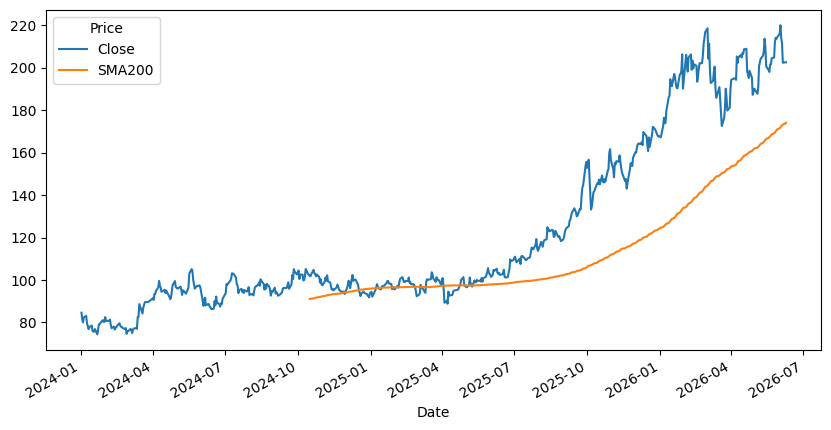

In [8]:
#Visualizar
df[['Close', 'SMA200']].plot(figsize=(10,5))

###Media Móvil Exponencial

In [9]:
#Calcular Media Móvil Exponencial de 200 días
df['EMA200'] = df['Close'].ewm(span=200, adjust=False).mean()

In [10]:
#Calcular Media Móvil Exponencial de 20 días
df['EMA20'] = df['Close'].ewm(span=20, adjust=False).mean()

<Axes: xlabel='Date'>

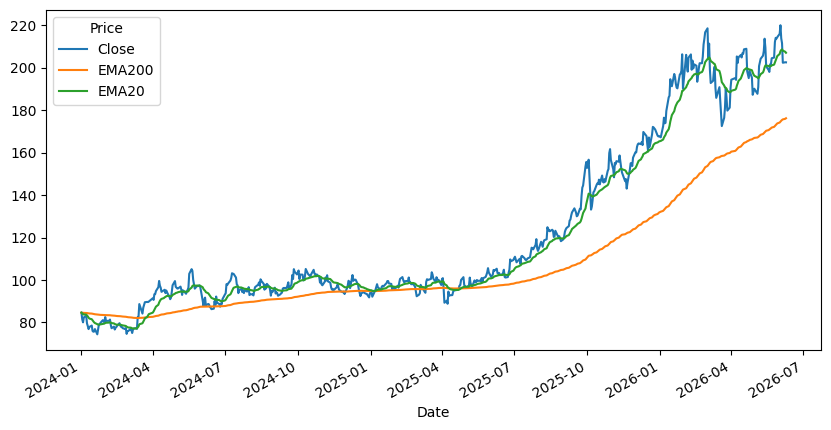

In [11]:
#Visualizar
df[['Close', 'EMA200', 'EMA20']].plot(figsize=(10,5))

##Descomposición Serie Temporal

###Modelo Aditivo

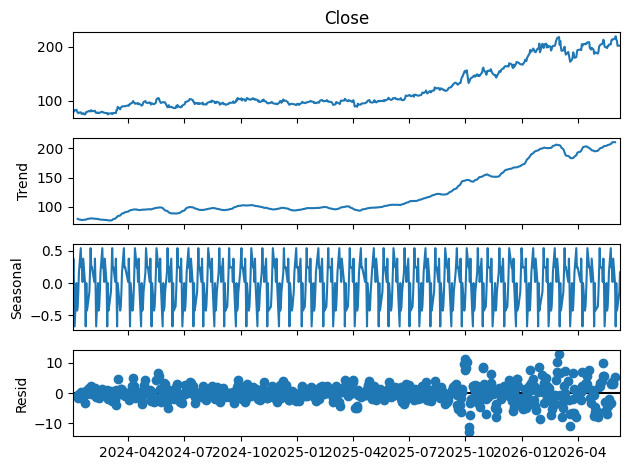

In [12]:
# Descomponer
result = seasonal_decompose(df['Close'], model='additive', period=12) # 12 meses en un año
result.plot()
plt.show()

###Modelo Multiplicativo

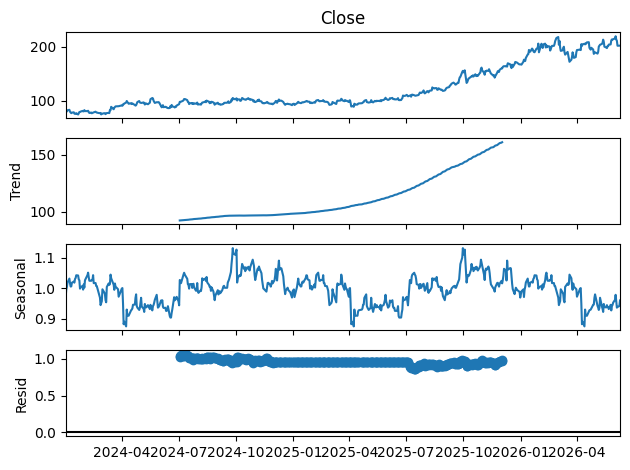

In [13]:
# Descomponer
result = seasonal_decompose(df['Close'], model='multiplicative', period=252) # 252 días hábiles en un año
result.plot()
plt.show()

In [14]:
# Seleccionar la columna de cierre y eliminar valores nulos
series = df['Close'].dropna()

In [15]:
# 2. Configurar y ejecutar la descomposición STL
# period: longitud de la estacionalidad. Para datos diarios, usualmente 365.
# robust=True ayuda a reducir la influencia de valores atípicos.
stl = STL(series, period=365, robust=True)
result = stl.fit()

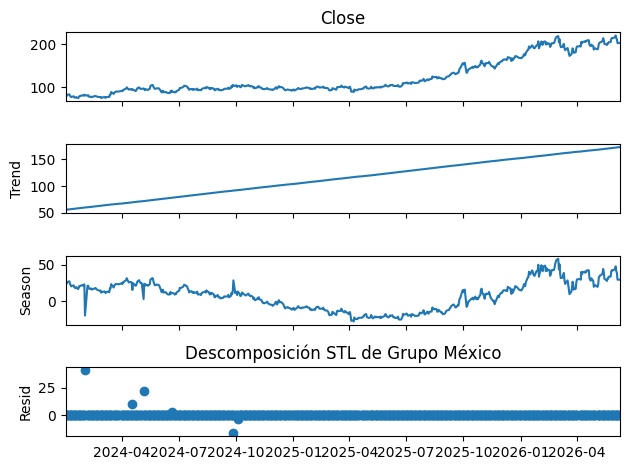

In [16]:
# 3. Visualizar los componentes
result.plot()
plt.title(f"Descomposición STL de Grupo México")
plt.tight_layout()
plt.show()

#Volatilidad

##Desviación Estándar

In [17]:
#Obtener datos
precios = df['Close']

In [18]:
# Método financiero estándar para rendimientos logarítmicos
df['Rendimientos_Log'] = np.log(precios / precios.shift(1))
print(df['Rendimientos_Log'])

Date
2024-01-02         NaN
2024-01-03   -0.037720
2024-01-04   -0.017483
2024-01-05    0.028422
2024-01-08    0.009406
                ...   
2026-06-03   -0.028553
2026-06-04   -0.010631
2026-06-05   -0.044484
2026-06-08    0.001087
2026-06-09   -0.000148
Name: Rendimientos_Log, Length: 609, dtype: float64


In [19]:
#Eliminar NaN solo de rendimientos
df.dropna(subset=['Rendimientos_Log'], inplace=True)
print(df['Rendimientos_Log'])

Date
2024-01-03   -0.037720
2024-01-04   -0.017483
2024-01-05    0.028422
2024-01-08    0.009406
2024-01-09   -0.044407
                ...   
2026-06-03   -0.028553
2026-06-04   -0.010631
2026-06-05   -0.044484
2026-06-08    0.001087
2026-06-09   -0.000148
Name: Rendimientos_Log, Length: 608, dtype: float64


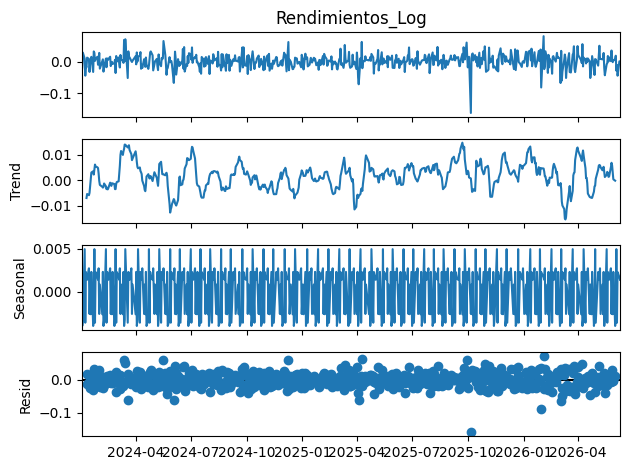

In [20]:
# Descomponer
result = seasonal_decompose(df['Rendimientos_Log'], model='additive', period=12) # 12 meses en un año
result.plot()
plt.show()

In [21]:
# 2. Configurar y ejecutar la descomposición STL
# period: longitud de la estacionalidad. Para datos diarios, usualmente 365.
# robust=True ayuda a reducir la influencia de valores atípicos.
stl = STL(df['Rendimientos_Log'], period=365, robust=True)
result = stl.fit()

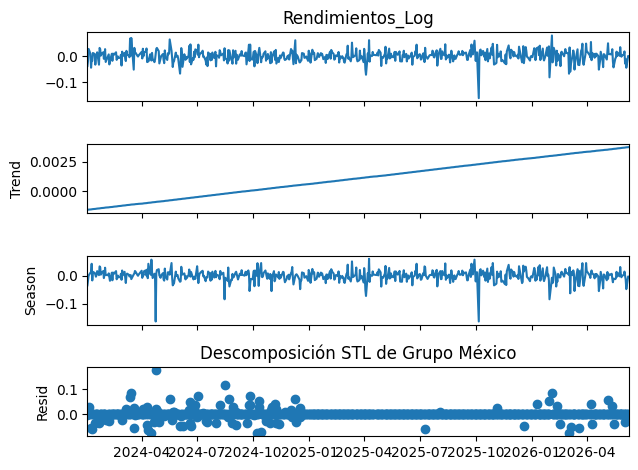

In [22]:
# 3. Visualizar los componentes
result.plot()
plt.title(f"Descomposición STL de Grupo México")
plt.tight_layout()
plt.show()

In [23]:
#Calcular la desviación estándar de los rendimientos (Volatilidad Diaria)
volatilidad_diaria = df['Rendimientos_Log'].std()

In [24]:
#Anualizar la volatilidad (multiplicando por la raíz cuadrada de 252 días hábiles al año)
volatilidad_anual = volatilidad_diaria * np.sqrt(252)

In [25]:
Volatilidad_diaria_porcentaje = volatilidad_diaria * 100
Volatilidad_anual_porcentaje = volatilidad_anual * 100

In [26]:
print(f"Volatilidad diaria: {volatilidad_diaria:.4f} = {Volatilidad_diaria_porcentaje:.4f} %")
print(f"Volatilidad anualizada: {volatilidad_anual:.4f} = {Volatilidad_anual_porcentaje:.4f} %")

Volatilidad diaria: 0.0223 = 2.2252 %
Volatilidad anualizada: 0.3532 = 35.3240 %


##Average True Range

In [27]:
#Calcular los 3 componentes del True Range (TR)
high_low = df['High'] - df['Low']
high_close = np.abs(df['High'] - df['Close'].shift(1))
low_close = np.abs(df['Low'] - df['Close'].shift(1))

In [28]:
print(high_low)

Date
2024-01-03    3.811026
2024-01-04    2.643276
2024-01-05    6.381882
2024-01-08    2.570863
2024-01-09    4.200276
                ...   
2026-06-03    6.209991
2026-06-04    7.380005
2026-06-05    8.479996
2026-06-08    4.629990
2026-06-09    8.199997
Length: 608, dtype: float64


In [29]:
print(high_close)

Date
2024-01-03         NaN
2024-01-04    0.117689
2024-01-05    6.046948
2024-01-08    0.887126
2024-01-09    0.253460
                ...   
2026-06-03    0.279999
2026-06-04    0.610001
2026-06-05    3.300003
2026-06-08    3.539993
2026-06-09    3.529999
Length: 608, dtype: float64


In [30]:
print(low_close)

Date
2024-01-03          NaN
2024-01-04     2.525587
2024-01-05     0.334934
2024-01-08     1.683737
2024-01-09     3.946816
                ...    
2026-06-03     6.489990
2026-06-04     6.770004
2026-06-05    11.779999
2026-06-08     1.089996
2026-06-09     4.669998
Length: 608, dtype: float64


In [31]:
#Unir y obtener el máximo de los 3 para cada día
ranges = pd.concat([high_low, high_close, low_close], axis=1)
true_range = ranges.max(axis=1)

In [32]:
print(true_range)

Date
2024-01-03     3.811026
2024-01-04     2.643276
2024-01-05     6.381882
2024-01-08     2.570863
2024-01-09     4.200276
                ...    
2026-06-03     6.489990
2026-06-04     7.380005
2026-06-05    11.779999
2026-06-08     4.629990
2026-06-09     8.199997
Length: 608, dtype: float64


In [33]:
#Calcular el ATR (suavizado clásico de Wilder, n=14)
atr_period = 14
atr = true_range.copy()

In [34]:
#El primer ATR es la media simple de los primeros 14 días
atr.iloc[atr_period-1] = true_range.iloc[:atr_period].mean()

In [35]:
#Iterar para aplicar la fórmula suavizada
for i in range(atr_period, len(true_range)):
    atr.iloc[i] = (atr.iloc[i-1] * (atr_period - 1) + true_range.iloc[i]) / atr_period

df['ATR_Calculado'] = atr
print(df[['High', 'Low', 'Close', 'ATR_Calculado']].tail())

Price             High         Low       Close  ATR_Calculado
Date                                                         
2026-06-03  219.619995  213.410004  213.710007       7.527991
2026-06-04  214.320007  206.940002  211.449997       7.517421
2026-06-05  208.149994  199.669998  202.250000       7.821890
2026-06-08  205.789993  201.160004  202.470001       7.593897
2026-06-09  206.000000  197.800003  202.440002       7.637190


In [36]:
#ATR diario
atr_diario = atr.mean()
print(f"ATR diario: {atr_diario:.4f}")

ATR diario: 4.2229


In [37]:
#ATR Anualizado
atr_anualizado = atr.mean() * np.sqrt(252)
print(f"ATR anualizado: {atr_anualizado:.4f}")

ATR anualizado: 67.0365


#Parámetros (p,d,q)

##Precios Diferenciados

###Serie Estacionaria


In [38]:
#Obtener datos
precios = df['Close']

In [39]:
# Función para realizar la prueba de Dickey-Fuller Aumentada
def probar_estacionariedad(serie, titulo):
    print(f"\n--- Prueba ADF para: {titulo} ---")
    resultado = adfuller(serie.dropna())
    estadistico = resultado[0]
    valor_p = resultado[1]
    criticos = resultado[4]

    print(f"Estadístico de Dickey-Fuller: {estadistico:.4f}")
    print(f"Valor p: {valor_p:.4f}")

    if valor_p < 0.05:
        print("Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).")
    else:
        print("Resultado: **La serie NO es ESTACIONARIA** (p >= 0.05, no se rechaza H0).")

    return valor_p

In [40]:
# Ejecutar prueba en Precios (Original)
probar_estacionariedad(precios, "Precios de Cierre (Original)")


--- Prueba ADF para: Precios de Cierre (Original) ---
Estadístico de Dickey-Fuller: -0.0127
Valor p: 0.9575
Resultado: **La serie NO es ESTACIONARIA** (p >= 0.05, no se rechaza H0).


np.float64(0.957468268824157)

####Diferenciando

In [41]:
# Calcular la primera diferencia del precio de cierre (columna 'Close')
differenced_prices = precios.diff().dropna()

In [42]:
# Mostrar los primeros elementos de la serie diferenciada
print(differenced_prices.head())

Date
2024-01-04   -1.412155
2024-01-05    2.308342
2024-01-08    0.778496
2024-01-09   -3.611877
2024-01-10   -1.213013
Name: Close, dtype: float64


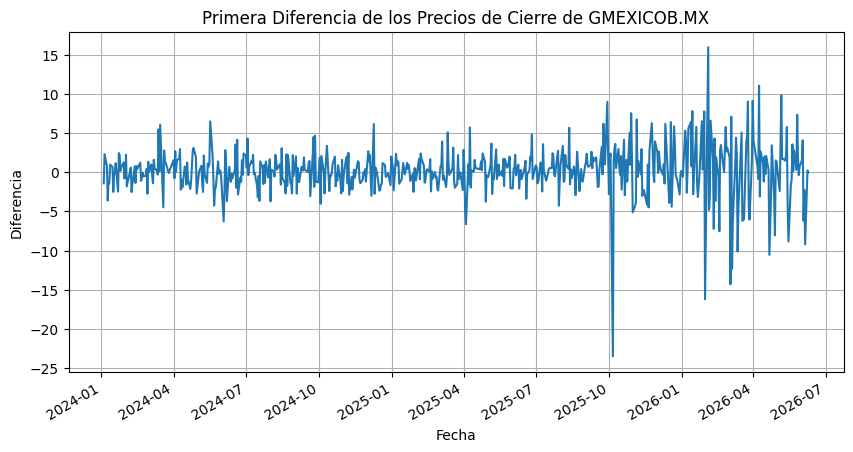

In [43]:
# Visualizar la serie diferenciada
plt.figure(figsize=(10,5))
differenced_prices.plot()
plt.title(f'Primera Diferencia de los Precios de Cierre de {"GMEXICOB.MX"}')
plt.xlabel('Fecha')
plt.ylabel('Diferencia')
plt.grid(True)
plt.show()

In [44]:
# Ejecutar prueba en serie diferenciada
probar_estacionariedad(differenced_prices, "Serie diferenciada")


--- Prueba ADF para: Serie diferenciada ---
Estadístico de Dickey-Fuller: -27.0227
Valor p: 0.0000
Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).


0.0

###Función de Autocorrelación

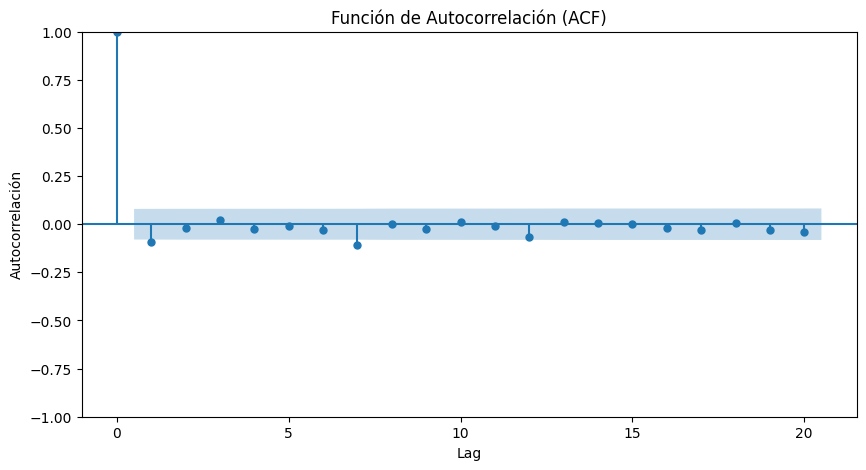

In [45]:
#Graficar la ACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(differenced_prices, lags=20, ax=ax) # Plot first 20 lags
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelación")
ax.set_title("Función de Autocorrelación (ACF)")
plt.show()

###Función de Autocorrelación Parcial (PACF)

<Figure size 1000x500 with 0 Axes>

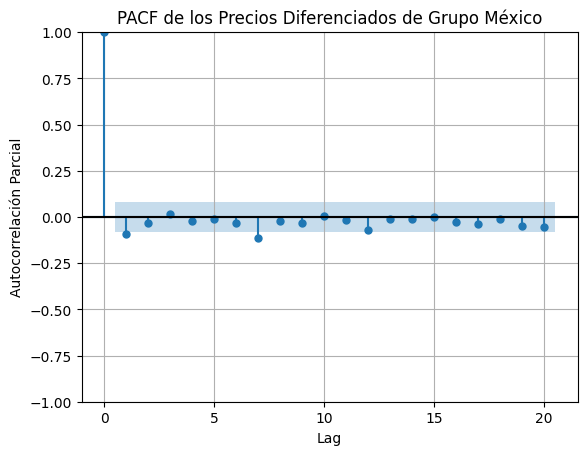

In [46]:
#Graficar la PACF
plt.figure(figsize=(10, 5))
plot_pacf(differenced_prices, lags=20, method='ywm') # method='ywm' es Yule-Walker modificado
plt.title('PACF de los Precios Diferenciados de Grupo México')
plt.xlabel('Lag')
plt.ylabel('Autocorrelación Parcial')
plt.axhline(y=0, color='k', linestyle='-')
plt.grid(True)
plt.show()

##Rendimientos Logarítmicos

In [101]:
# Método financiero estándar para rendimientos logarítmicos
df['Rendimientos_Log'] = np.log(precios / precios.shift(1))
print(df['Rendimientos_Log'])

Date
2024-01-03         NaN
2024-01-04   -0.017483
2024-01-05    0.028422
2024-01-08    0.009406
2024-01-09   -0.044407
                ...   
2026-06-03   -0.028553
2026-06-04   -0.010631
2026-06-05   -0.044484
2026-06-08    0.001087
2026-06-09   -0.000148
Name: Rendimientos_Log, Length: 608, dtype: float64


In [102]:
#Eliminar NaN solo de rendimientos
df.dropna(subset=['Rendimientos_Log'], inplace=True)
print(df['Rendimientos_Log'])

Date
2024-01-04   -0.017483
2024-01-05    0.028422
2024-01-08    0.009406
2024-01-09   -0.044407
2024-01-10   -0.015367
                ...   
2026-06-03   -0.028553
2026-06-04   -0.010631
2026-06-05   -0.044484
2026-06-08    0.001087
2026-06-09   -0.000148
Name: Rendimientos_Log, Length: 607, dtype: float64


In [103]:
#Prueba de estacionariedad (Dickey-Fuller Aumentada)
probar_estacionariedad(df['Rendimientos_Log'], "Retornos Logarítmicos")


--- Prueba ADF para: Retornos Logarítmicos ---
Estadístico de Dickey-Fuller: -26.8735
Valor p: 0.0000
Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).


0.0

###Función de Autocorrelación

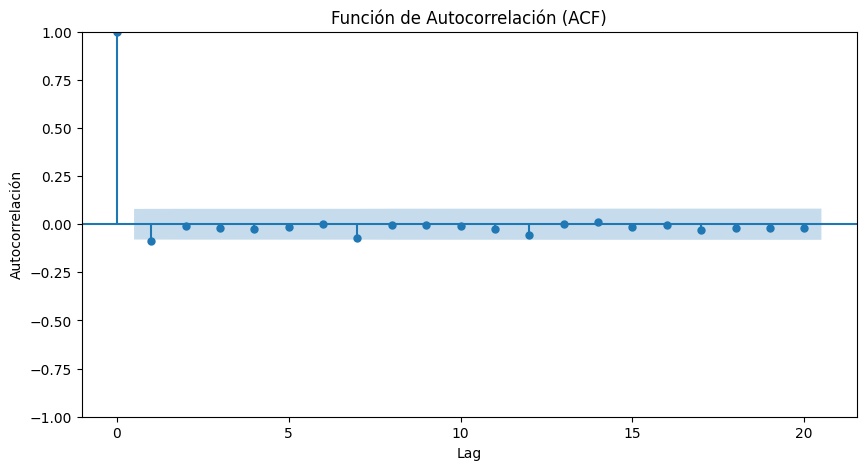

In [104]:
#Gráfica ACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(df['Rendimientos_Log'], lags=20, ax=ax)
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelación")
ax.set_title("Función de Autocorrelación (ACF)")
plt.show()

###Función de Autocorrelación Parcial

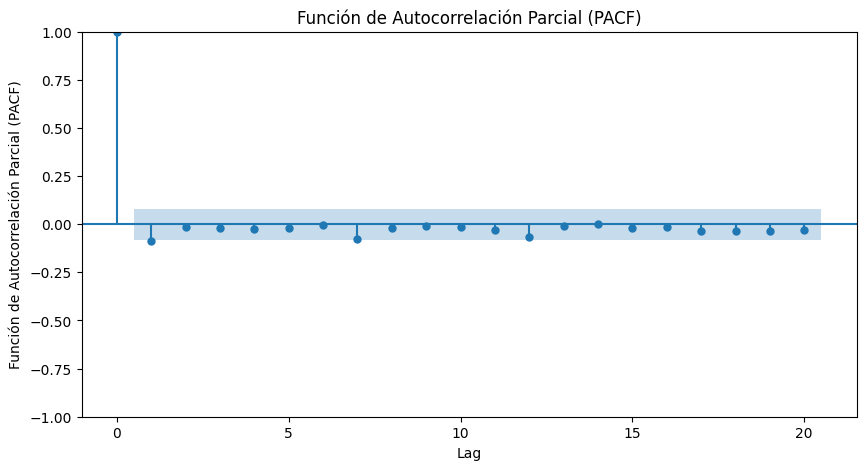

In [106]:
#Gráfica PACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_pacf(df['Rendimientos_Log'], lags=20, ax=ax)
ax.set_xlabel("Lag")
ax.set_ylabel("Función de Autocorrelación Parcial (PACF)")
ax.set_title("Función de Autocorrelación Parcial (PACF)")
plt.show()

#ARIMA

In [107]:
modelo = ARIMA(df['Rendimientos_Log'].dropna(),
               order=(0,0,0))
resultado = modelo.fit()

print(resultado.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:       Rendimientos_Log   No. Observations:                  607
Model:                          ARIMA   Log Likelihood                1450.090
Date:                Tue, 09 Jun 2026   AIC                          -2896.180
Time:                        21:16:13   BIC                          -2887.363
Sample:                             0   HQIC                         -2892.749
                                - 607                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0015      0.001      1.610      0.107      -0.000       0.003
sigma2         0.0005   1.52e-05     32.493      0.000       0.000       0.001
Ljung-Box (L1) (Q):                   4.78   Jarque-

In [110]:
from statsmodels.stats.diagnostic import het_arch

arch_test = het_arch(df['Rendimientos_Log'].dropna())

print("LM Statistic:", arch_test[0])
print("p-value:", arch_test[1])

LM Statistic: 7.731249087244336
p-value: 0.6550693638892845


In [122]:
for orden in [(0,0,0),(1,0,0),(0,0,1),(1,0,1)]:
  modelo = ARIMA(df['Rendimientos_Log'].dropna(),order=orden)
  resultado = modelo.fit()

  print(orden, resultado.aic)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


(0, 0, 0) -2896.179794372736
(1, 0, 0) -2898.952389451063


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


(0, 0, 1) -2899.082490104439
(1, 0, 1) -2897.206639386304


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [123]:
modelo = ARIMA(df['Rendimientos_Log'].dropna(),
               order=(0,0,1))

resultado = modelo.fit()

print(resultado.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:       Rendimientos_Log   No. Observations:                  607
Model:                 ARIMA(0, 0, 1)   Log Likelihood                1452.541
Date:                Tue, 09 Jun 2026   AIC                          -2899.082
Time:                        21:25:56   BIC                          -2885.857
Sample:                             0   HQIC                         -2893.937
                                - 607                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0015      0.001      1.775      0.076      -0.000       0.003
ma.L1         -0.0895      0.037     -2.397      0.017      -0.163      -0.016
sigma2         0.0005   1.55e-05     31.486      0.0

In [124]:
residuos = resultado.resid

for lag in [5,10,15,20]:
    lm, pvalue, _, _ = het_arch(residuos, nlags=lag)
    print(f"Lag={lag}: p-value={pvalue}")

Lag=5: p-value=0.424081365645103
Lag=10: p-value=0.761028990320897
Lag=15: p-value=0.927495063816079
Lag=20: p-value=0.976062199428442


In [108]:
residuos = resultado.resid

In [109]:
garch = arch_model(
    residuos,
    mean='Zero',
    vol='GARCH',
    p=1,
    q=1
)

resultado_garch = garch.fit()
print(resultado_garch.summary())

Iteration:      1,   Func. Count:      5,   Neg. LLF: 1325509.4759037308
Iteration:      2,   Func. Count:     11,   Neg. LLF: -1002.2466162464656
Iteration:      3,   Func. Count:     19,   Neg. LLF: -1449.6730304490513
Iteration:      4,   Func. Count:     26,   Neg. LLF: -1427.6102261846404
Iteration:      5,   Func. Count:     32,   Neg. LLF: -1374.7668468609136
Iteration:      6,   Func. Count:     38,   Neg. LLF: -1453.5182353654836
Iteration:      7,   Func. Count:     45,   Neg. LLF: -1457.1201812971713
Iteration:      8,   Func. Count:     49,   Neg. LLF: -1457.1201889792687
Iteration:      9,   Func. Count:     52,   Neg. LLF: -1457.1201889792262
Optimization terminated successfully    (Exit mode 0)
            Current function value: -1457.1201889792687
            Iterations: 9
            Function evaluations: 52
            Gradient evaluations: 9
                       Zero Mean - GARCH Model Results                        
Dep. Variable:                   None   R-squar

/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0004926. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


##Opcion 1

In [56]:
modelo = ARIMA(df['rendimiento_log'], order=(0, 1, 0))
modelo_ajustado = modelo.fit()
print(modelo_ajustado.summary())

                               SARIMAX Results                                
Dep. Variable:        rendimiento_log   No. Observations:                  608
Model:                 ARIMA(0, 1, 0)   Log Likelihood                1203.821
Date:                Tue, 09 Jun 2026   AIC                          -2405.642
Time:                        20:53:18   BIC                          -2401.234
Sample:                             0   HQIC                         -2403.927
                                - 608                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.0011   3.65e-05     29.421      0.000       0.001       0.001
Ljung-Box (L1) (Q):                 175.32   Jarque-Bera (JB):               350.61
Prob(Q):                              0.00   Pr

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [88]:
#GARCH se ajusta sobre los residuos del modelo de la media:
residuos = modelo_ajustado.resid

In [89]:
print(residuos.head())

Date
2024-01-03         NaN
2024-01-04   -0.017483
2024-01-05    0.045905
2024-01-08   -0.019016
2024-01-09   -0.053813
dtype: float64


In [98]:
#Ajustar un GARCH(1,1)
#¿Por qué mean='Zero'? Porque la media ya fue modelada por ARIMA. Ahora GARCH sólo modela la volatilidad de los residuos.

modelo_garch = arch_model(residuos.dropna(), mean='Zero', vol='GARCH',p=1, q=1)

resultado_garch = modelo_garch.fit()

print(resultado_garch.summary())

Iteration:      1,   Func. Count:      4,   Neg. LLF: -1255.7817570395848
Optimization terminated successfully    (Exit mode 0)
            Current function value: -1255.7817577728765
            Iterations: 5
            Function evaluations: 4
            Gradient evaluations: 1
                       Zero Mean - GARCH Model Results                        
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.002
Vol Model:                      GARCH   Log-Likelihood:                1255.78
Distribution:                  Normal   AIC:                          -2505.56
Method:            Maximum Likelihood   BIC:                          -2492.34
                                        No. Observations:                  607
Date:                Tue, Jun 09 2026   Df Residuals:                      607
Time:                        21:01:02   Df Model:                            0
       

/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.001072. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [99]:
#Obtener la volatilidad estimada
volatilidad = resultado_garch.conditional_volatility

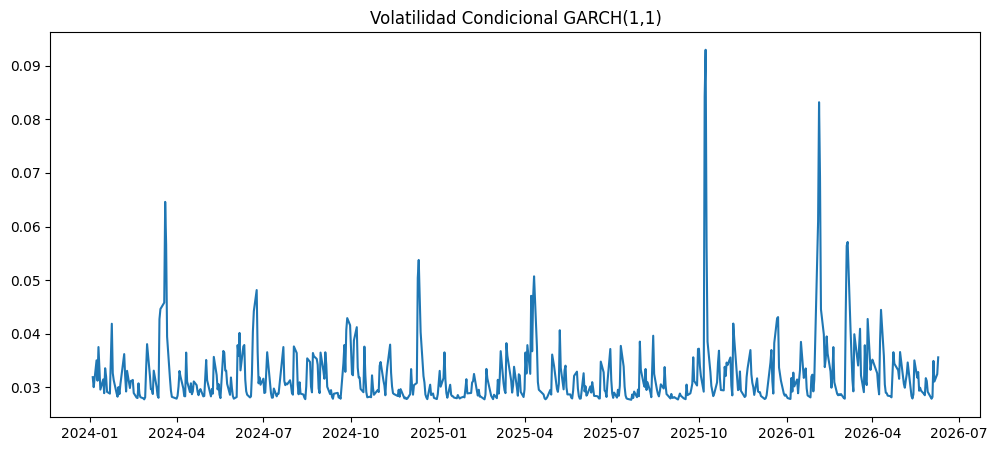

In [100]:
plt.figure(figsize=(12,5))
plt.plot(volatilidad)
plt.title('Volatilidad Condicional GARCH(1,1)')
plt.show()

###Opcion 2

In [57]:
# Fit the ARIMA model
# Initial ARIMA Model parameters
p, d, q = 0,1,0
model = ARIMA(df['rendimiento_log'], order=(p, d, q))
model_fit = model.fit()
model_summary = model_fit.summary()
model_summary

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:        rendimiento_log   No. Observations:                  608
Model:                 ARIMA(0, 1, 0)   Log Likelihood                1203.821
Date:                Tue, 09 Jun 2026   AIC                          -2405.642
Time:                        20:53:28   BIC                          -2401.234
Sample:                             0   HQIC                         -2403.927
                                - 608                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.0011   3.65e-05     29.421      0.000       0.001       0.001
===================================================================================
Ljung-Box (L1) (Q):                 175.32   Jarque-Bera (JB):               350.61
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.47   Skew:                            -0.02
Prob(H) (two-sided):                  0.01   Kurtosis:                         6.72
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

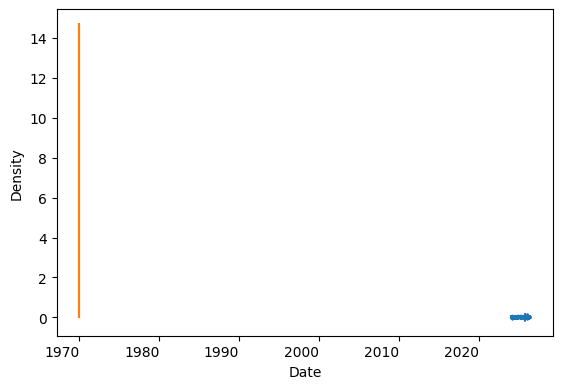

In [58]:
# plot residual errors
residuals = model_fit.resid
residuals.plot()
residuals.plot(kind='kde')
plt.show()

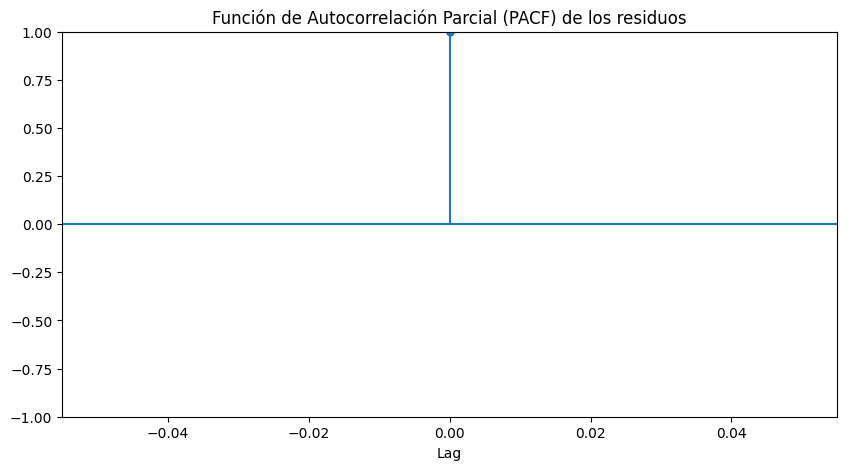

In [59]:
#Gráfica PACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_pacf(residuals, lags=20, ax=ax)
ax.set_xlabel("Lag")
ax.set_title("Función de Autocorrelación Parcial (PACF) de los residuos")
plt.show()

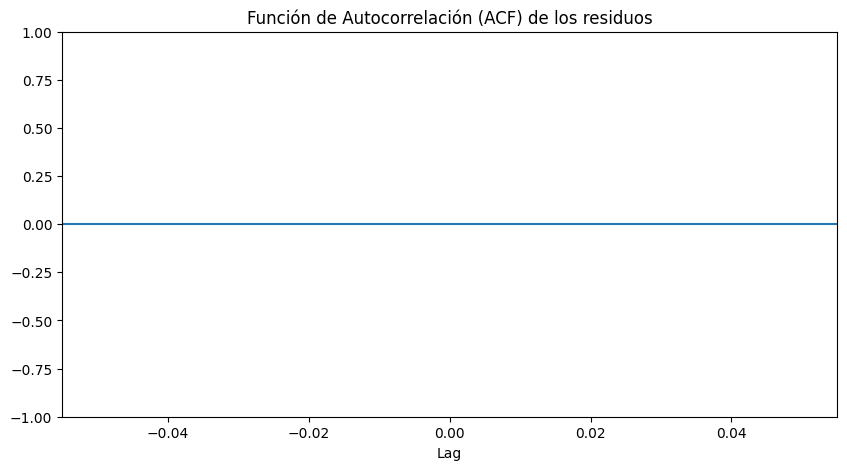

In [60]:
#Graficar la ACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(residuals, lags=20, ax=ax) # Plot first 20 lags
ax.set_xlabel("Lag")
ax.set_title("Función de Autocorrelación (ACF) de los residuos")
plt.show()

In [61]:
##Ejemplo básico
model = auto_arima(
    df['rendimiento_log'].dropna(),  # Serie temporal, asegurándose de que no haya NaN
    start_p=0,          # Orden AR inicial
    start_q=0,          # Orden MA inicial
    max_p=5,            # Máximo orden AR
    max_q=5,            # Máximo orden MA
    m=1,                # Periodo estacional (1 si no hay estacionalidad)
    seasonal=False,     # True si la serie es estacional
    stepwise=True,      # Usa búsqueda paso a paso para mayor velocidad
    trace=True          # Muestra el proceso de selección
)

# Resumen del modelo encontrado
print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-2895.416, Time=0.06 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-2897.658, Time=0.06 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-2897.725, Time=0.05 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-2895.749, Time=0.08 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=-2895.735, Time=0.15 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-2895.369, Time=0.20 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=-2899.084, Time=0.21 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=-2896.180, Time=0.16 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-2897.209, Time=0.22 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=-2897.158, Time=0.35 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-2898.952, Time=0.26 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=-2895.155, Time=1.54 sec

Best model:  ARIMA(0,0,1)(0,0,0)[0] intercept
Total fit time: 3.347 seconds
                               SARIMAX Results                              

#Monte Carlo

In [62]:
#Calcular los retornos
retornos = df['Rendimientos_Log'].dropna()
print (retornos)

Date
2024-01-03   -0.037720
2024-01-04   -0.017483
2024-01-05    0.028422
2024-01-08    0.009406
2024-01-09   -0.044407
                ...   
2026-06-03   -0.028553
2026-06-04   -0.010631
2026-06-05   -0.044484
2026-06-08    0.001087
2026-06-09   -0.000148
Name: Rendimientos_Log, Length: 608, dtype: float64


In [63]:
# Ejecutar prueba en Precios Retornos
probar_estacionariedad(retornos, "Retornos")


--- Prueba ADF para: Retornos ---
Estadístico de Dickey-Fuller: -26.8694
Valor p: 0.0000
Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).


0.0

In [64]:
media_retornos = retornos.mean()
print(f"La media de los retornos es: {media_retornos:.6f}")

La media de los retornos es: 0.001435


In [65]:
#Calculamos la desviación estándar
desviacion_retornos = retornos.std()
print(f"La desviación de los retornos es: {desviacion_retornos:.6f}")

La desviación de los retornos es: 0.022252


In [66]:
# Definir el número de simulaciones (escenarios) y el número de días a proyectar
num_simulaciones = 100 # Número de escenarios Monte Carlo
num_dias_a_proyectar = 100 # Número de días en el futuro para cada simulación

In [67]:
# Obtener el último precio de cierre del DataFrame
ultimo_precio_cierre = df['Close'].iloc[-1]
print("El último precio de cierre es: $", ultimo_precio_cierre)

El último precio de cierre es: $ 202.44000244140625


In [68]:
# Lista para almacenar todos los escenarios de precios simulados
monte_carlo_simulaciones = []

In [69]:
for _ in range(num_simulaciones):
    # Para cada simulación, empezar con el último precio conocido
    current_scenario_prices = [ultimo_precio_cierre]
    for _ in range(num_dias_a_proyectar):
        # Generar números aleatorios basado
        aleatorio = np.random.normal(0, 1)
        # Calcular el siguiente precio
        dt = 1/252
        precio_siguiente = current_scenario_prices[-1] * np.exp((media_retornos - 0.5 * desviacion_retornos**2) * dt + desviacion_retornos * np.sqrt(dt) * aleatorio)
        current_scenario_prices.append(precio_siguiente)
    monte_carlo_simulaciones.append(current_scenario_prices)

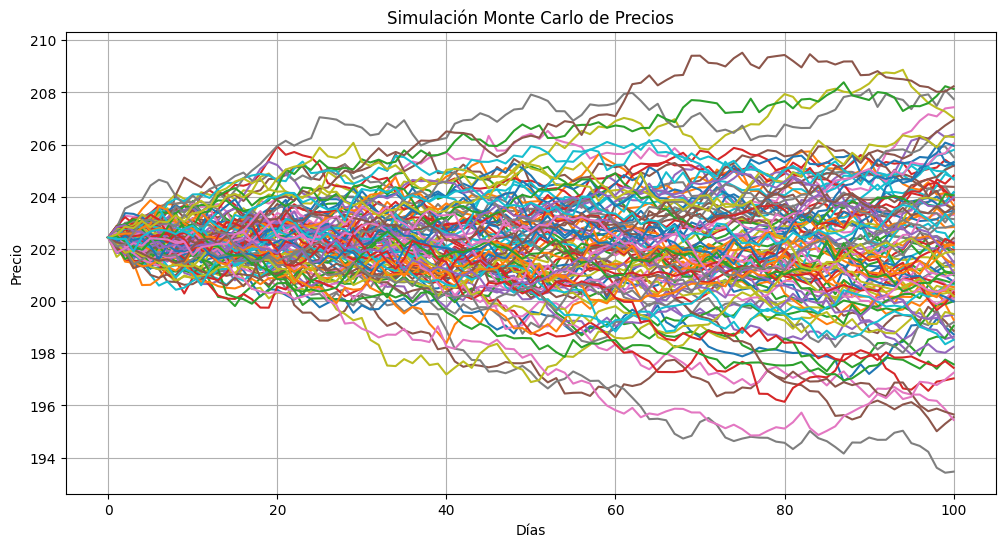

In [70]:
plt.figure(figsize=(12,6))

for simulacion in monte_carlo_simulaciones:
    plt.plot(simulacion)

plt.title('Simulación Monte Carlo de Precios')
plt.xlabel('Días')
plt.ylabel('Precio')
plt.grid(True)

plt.show()

##Predicción precio

In [71]:
# Re-creating monte_carlo_simulaciones_df as a DataFrame
# This assumes 'monte_carlo_simulaciones' is still available from previous cells
monte_carlo_simulaciones_df = pd.DataFrame(monte_carlo_simulaciones).T

In [72]:
# Se extrae la última columna de los precios simulados
ultima_columna = monte_carlo_simulaciones_df.iloc[:,-1]
print(ultima_columna)

0      202.440002
1      202.375409
2      202.384188
3      201.904653
4      202.467512
          ...    
96     203.356735
97     203.137003
98     202.865665
99     203.342822
100    202.931118
Name: 99, Length: 101, dtype: float64


In [73]:
#Precio de cierre número 100
precio_cien = df['Close'][102]
print(f"El precio de cierre número cien es: $ {precio_cien: .2f}")

El precio de cierre número cien es: $  96.53


/tmp/ipykernel_16433/2497414103.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  precio_cien = df['Close'][102]


In [74]:
#Calcular Ganancias / Pérdidas

Ganancia_Pérdida = []
for precio in ultima_columna:
    ganancia_perdida = precio - precio_cien
    Ganancia_Pérdida.append(ganancia_perdida)

In [75]:
# Re-creating monte_carlo_simulaciones_df as a DataFrame
# This assumes 'monte_carlo_simulaciones' is still available from previous cells
Ganancia_Pérdida = pd.DataFrame(Ganancia_Pérdida).T
print(Ganancia_Pérdida)

          0           1           2           3           4           5    \
0  105.905884  105.841291  105.850069  105.370535  105.933393  106.136282   

          6          7           8           9    ...         91          92   \
0  106.204588  106.16247  106.036045  106.241249  ...  106.223876  106.600411   

          93          94          95          96          97          98   \
0  106.976707  107.150641  107.086386  106.822616  106.602884  106.331546   

          99          100  
0  106.808703  106.396999  

[1 rows x 101 columns]


In [76]:
#Contar %Ganancias y %Pérdidas si el precio de compra es lo que vale el precio de cierre número cien
if isinstance(Ganancia_Pérdida, list):
    Ganancia_Pérdida = pd.DataFrame(Ganancia_Pérdida).T

Ganancia = (Ganancia_Pérdida > 0).sum().sum()
Perdida = (Ganancia_Pérdida < 0).sum().sum()

# Obtener el número total de simulaciones
num_simulaciones = Ganancia_Pérdida.size

# Calcular porcentajes
porcentaje_ganancia = (Ganancia / num_simulaciones) * 100
porcentaje_perdida = (Perdida / num_simulaciones) * 100

print(f"Número de simulaciones con ganancia: {Ganancia} ({porcentaje_ganancia:.2f} %)")
print(f"Número de simulaciones con pérdida: {Perdida} ({porcentaje_perdida:.2f} %)")
print(f"Número total de simulaciones: {num_simulaciones}")

Número de simulaciones con ganancia: 101 (100.00 %)
Número de simulaciones con pérdida: 0 (0.00 %)
Número total de simulaciones: 101


In [77]:
#Ganancia potencial
Ganancia_potencial = Ganancia_Pérdida.mean(axis=1).iloc[0]
print(f"Ganancia Potencial: $ {Ganancia_potencial: .2f}")

Ganancia Potencial: $  106.70


In [78]:
#Precio Potencial
Precio_potencial = precio_cien + Ganancia_potencial
print(f"Precio Potencial: $ {Precio_potencial: .2f}")

Precio Potencial: $  203.23


##Error Cuadrático Medio (RMSE)


In [79]:
monte_carlo_simulaciones_df = pd.DataFrame(monte_carlo_simulaciones).T

In [80]:
prediccion_mc = monte_carlo_simulaciones_df.mean(axis=1)

In [81]:
ultimos_101 = precios.iloc[-103:-2]
print(ultimos_101)

Date
2026-01-08    173.993454
2026-01-09    179.561325
2026-01-12    185.956985
2026-01-13    186.696091
2026-01-14    194.491104
                 ...    
2026-06-01    215.830002
2026-06-02    219.899994
2026-06-03    213.710007
2026-06-04    211.449997
2026-06-05    202.250000
Name: Close, Length: 101, dtype: float64


In [82]:
print(len(ultimos_101))
print(len(prediccion_mc))

101
101


In [83]:
rmse = np.sqrt(mean_squared_error(ultimos_101, prediccion_mc[0:]))
print(f"RMSE Monte Carlo: {rmse:.4f}")

RMSE Monte Carlo: 10.7870


In [84]:
rmse_porcentaje = (rmse / ultimos_101.mean()) * 100
print(f"% RMSE Monte Carlo: {rmse_porcentaje:.4f} %")

% RMSE Monte Carlo: 5.4313 %


##Error Cuadrático Medio (MAE)

In [85]:
mae = mean_absolute_error(ultimos_101, prediccion_mc)

print(f"MAE Monte Carlo: {mae:.4f}")

MAE Monte Carlo: 8.4571
